<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Humidity/XAI_Humidity_3_Iterations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/cleaned_weather_data (1).csv")

print("Dataset loaded successfully!")
print(df.shape)

df.head()

Dataset loaded successfully!
(130003, 43)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,condition_text_before,wind_direction_before
0,United States of America,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,16.1,61.0,2,...,1,1,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55,Clear,SW
1,Honduras,Tegucigalpa,14.10,-87.22,America/Tegucigalpa,1715849100,2024-05-16 02:45:00,23.0,73.4,32,...,2,2,05:22 AM,06:09 PM,12:52 PM,12:55 AM,Waxing Gibbous,55,Partly cloudy,WSW
2,El Salvador,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,26.0,78.8,23,...,2,2,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55,Moderate or heavy rain with thunder,S
3,Guatemala,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,20.0,68.0,19,...,4,10,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55,Mist,S
4,Belize,Belmopan,17.25,-88.77,America/Belize,1715849100,2024-05-16 02:45:00,26.0,78.9,30,...,1,1,05:23 AM,06:20 PM,12:56 PM,01:04 AM,Waxing Gibbous,55,Overcast,E


In [2]:

import pandas as pd

# -----------------------------
# TARGET
# -----------------------------
target = "humidity"

# -----------------------------
# 1. REMOVE UNSUITABLE FEATURES
# -----------------------------
# Reasons:
# - duplicate units
# - weak usefulness / near-zero correlation
# - timestamp less interpretable unless converted to datetime features
# - remove duplicate-index style features if you want cleaner predictors

remove_features = [
    "temperature_fahrenheit",        # duplicate of temperature_celsius
    "wind_kph",                      # duplicate of wind_mph
    "pressure_in",                   # duplicate of pressure_mb
    "precip_in",                     # duplicate of precip_mm
    "feels_like_fahrenheit",         # duplicate of feels_like_celsius
    "visibility_miles",              # duplicate of visibility_km
    "gust_kph",                      # duplicate of gust_mph
    "moon_illumination",             # almost no correlation
    "wind_direction",                # very weak correlation
    "pressure_mb",                   # almost no correlation
    "last_updated_epoch"             # use only if converted into useful datetime features
]

# drop only if they exist
existing_remove_features = [col for col in remove_features if col in df.columns]

print("Features removed:")
print(existing_remove_features)

df_clean = df.drop(columns=existing_remove_features, errors="ignore")

# -----------------------------
# 2. SELECT MOST SUITABLE 15 FEATURES
# -----------------------------
# Chosen based on:
# - stronger correlation with humidity
# - no duplicate-unit columns
# - no target leakage
selected_features = [
    "uv_index",
    "cloud",
    "condition_text",
    "air_quality_Ozone",
    "temperature_celsius",
    "feels_like_celsius",
    "air_quality_us-epa-index",
    "air_quality_gb-defra-index",
    "longitude",
    "precip_mm",
    "air_quality_PM10",
    "air_quality_PM2.5",
    "visibility_km",
    "air_quality_Sulphur_dioxide",
    "latitude"
]

# keep only features that actually exist
selected_features = [col for col in selected_features if col in df_clean.columns]

print("\nSelected suitable features for humidity:")
print(selected_features)

# -----------------------------
# 3. FINAL DATASET FOR humidity
# -----------------------------
X_humidity = df_clean[selected_features]
y_humidity = df_clean[target]

final_humidity_df = pd.concat([X_humidity, y_humidity], axis=1)

print("\nFinal dataset shape:")
print(final_humidity_df.shape)

print("\nFinal dataset columns:")
print(final_humidity_df.columns.tolist())

# preview
final_humidity_df.head()


Features removed:
['temperature_fahrenheit', 'wind_kph', 'pressure_in', 'precip_in', 'feels_like_fahrenheit', 'visibility_miles', 'gust_kph', 'moon_illumination', 'wind_direction', 'pressure_mb', 'last_updated_epoch']

Selected suitable features for humidity:
['uv_index', 'cloud', 'condition_text', 'air_quality_Ozone', 'temperature_celsius', 'feels_like_celsius', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'longitude', 'precip_mm', 'air_quality_PM10', 'air_quality_PM2.5', 'visibility_km', 'air_quality_Sulphur_dioxide', 'latitude']

Final dataset shape:
(130003, 16)

Final dataset columns:
['uv_index', 'cloud', 'condition_text', 'air_quality_Ozone', 'temperature_celsius', 'feels_like_celsius', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'longitude', 'precip_mm', 'air_quality_PM10', 'air_quality_PM2.5', 'visibility_km', 'air_quality_Sulphur_dioxide', 'latitude', 'humidity']


,uv_index,cloud,condition_text,air_quality_Ozone,temperature_celsius,feels_like_celsius,air_quality_us-epa-index,air_quality_gb-defra-index,longitude,precip_mm,air_quality_PM10,air_quality_PM2.5,visibility_km,air_quality_Sulphur_dioxide,latitude,humidity
0,1.0,0,2,62.2,16.1,16.1,1,1,-120.49,0.00,7.1,6.3,16.0,0.2,46.60,58
1,1.0,37,32,23.3,23.0,25.3,2,2,-87.22,0.28,25.3,19.0,10.0,1.4,14.10,78
2,1.0,50,23,5.9,26.0,30.2,2,2,-89.20,0.30,28.1,20.4,10.0,7.5,13.71,94
3,1.0,100,19,0.4,20.0,20.0,4,10,-90.53,0.09,178.1,132.0,5.0,19.3,14.62,88
4,1.0,94,30,34.0,26.0,29.6,1,1,-88.77,0.00,32.1,7.7,10.0,0.2,17.25,89


In [3]:
removed_table = pd.DataFrame({
    "Removed Features": existing_remove_features
})

selected_table = pd.DataFrame({
    "Selected Features for PM2.5": selected_features
})

print("Removed Features Table")
display(removed_table)

print("Selected Features Table")
display(selected_table)


Removed Features Table


,Removed Features
0,temperature_fahrenheit
1,wind_kph
2,pressure_in
3,precip_in
4,feels_like_fahrenheit
5,visibility_miles
6,gust_kph
7,moon_illumination
8,wind_direction
9,pressure_mb


Selected Features Table


,Selected Features for PM2.5
0,uv_index
1,cloud
2,condition_text
3,air_quality_Ozone
4,temperature_celsius
5,feels_like_celsius
6,air_quality_us-epa-index
7,air_quality_gb-defra-index
8,longitude
9,precip_mm


In [4]:

from google.colab import files

# Save humidity dataset
final_humidity_df.to_csv("final_humidity_dataset.csv", index=False)

# Download to your computer
files.download("final_humidity_dataset.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:

import pandas as pd
import numpy as np

# -----------------------------
# TARGET AND SELECTED FEATURES
# -----------------------------
target = "humidity"

selected_features = [
    "uv_index",
    "cloud",
    "condition_text",
    "air_quality_Ozone",
    "temperature_celsius",
    "feels_like_celsius",
    "air_quality_us-epa-index",
    "air_quality_gb-defra-index",
    "longitude",
    "precip_mm",
    "air_quality_PM10",
    "air_quality_PM2.5",
    "visibility_km",
    "air_quality_Sulphur_dioxide",
    "latitude"
]

# -----------------------------
# BUILD DATASET
# -----------------------------
humidity_df = df[["last_updated"] + selected_features + [target]].copy()

# convert datetime
humidity_df["last_updated"] = pd.to_datetime(humidity_df["last_updated"], errors="coerce")

# remove invalid dates
humidity_df = humidity_df.dropna(subset=["last_updated"])

# sort by time (VERY important for time-series / online learning)
humidity_df = humidity_df.sort_values("last_updated").reset_index(drop=True)

# drop remaining missing values
humidity_df = humidity_df.dropna().reset_index(drop=True)

print("Humidity dataset shape:", humidity_df.shape)
humidity_df.head()

Humidity dataset shape: (130003, 17)


,last_updated,uv_index,cloud,condition_text,air_quality_Ozone,temperature_celsius,feels_like_celsius,air_quality_us-epa-index,air_quality_gb-defra-index,longitude,precip_mm,air_quality_PM10,air_quality_PM2.5,visibility_km,air_quality_Sulphur_dioxide,latitude,humidity
0,2024-05-16 01:45:00,1.0,0,2,62.2,16.1,16.1,1,1,-120.49,0.00,7.1,6.3,16.0,0.2,46.60,58
1,2024-05-16 02:45:00,1.0,37,32,23.3,23.0,25.3,2,2,-87.22,0.28,25.3,19.0,10.0,1.4,14.10,78
2,2024-05-16 02:45:00,1.0,50,23,5.9,26.0,30.2,2,2,-89.20,0.30,28.1,20.4,10.0,7.5,13.71,94
3,2024-05-16 02:45:00,1.0,100,19,0.4,20.0,20.0,4,10,-90.53,0.09,178.1,132.0,5.0,19.3,14.62,88
4,2024-05-16 02:45:00,1.0,94,30,34.0,26.0,29.6,1,1,-88.77,0.00,32.1,7.7,10.0,0.2,17.25,89


In [6]:

# -----------------------------
# 80% TRAIN / 20% TEST
# -----------------------------
split_index = int(0.8 * len(humidity_df))

train_df = humidity_df.iloc[:split_index].copy()
test_df = humidity_df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (104002, 17)
Test shape : (26001, 17)


In [7]:
from google.colab import files

# Save training dataset
train_df.to_csv("humidity_training_dataset.csv", index=False)

# Save testing dataset
test_df.to_csv("humidity_testing_dataset.csv", index=False)

# Download both files
files.download("humidity_training_dataset.csv")
files.download("humidity_testing_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:

# -----------------------------
# ITERATION 1, 2, 3 FROM TRAINING DATA
# -----------------------------
n_train = len(train_df)

iter1 = train_df.iloc[:int(0.33 * n_train)].copy()
iter2 = train_df.iloc[int(0.33 * n_train):int(0.66 * n_train)].copy()
iter3 = train_df.iloc[int(0.66 * n_train):].copy()

print("Iteration 1 shape:", iter1.shape)
print("Iteration 2 shape:", iter2.shape)
print("Iteration 3 shape:", iter3.shape)

Iteration 1 shape: (34320, 17)
Iteration 2 shape: (34321, 17)
Iteration 3 shape: (35361, 17)


In [9]:
def get_xy(data):
    X = data[selected_features]
    y = data[target]
    return X, y

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    accuracy = r2 * 100
    return mse, rmse, mae, r2, accuracy

In [10]:
X1, y1 = get_xy(iter1)
X2, y2 = get_xy(iter2)
X3, y3 = get_xy(iter3)

X_test, y_test = get_xy(test_df)

print(X1.shape, X2.shape, X3.shape, X_test.shape)

(34320, 15) (34321, 15) (35361, 15) (26001, 15)


In [11]:

results = []            # for iteration-wise RMSE comparison table
all_iteration_metrics = []  # for full training iteration metrics of each model
final_test_results = [] # for final unseen test results

In [12]:

# !pip install xgboost

import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# Iteration 1
xgb_model.fit(X1, y1)
xgb_pred1 = xgb_model.predict(X1)
mse, rmse, mae, r2, acc = calculate_metrics(y1, xgb_pred1)
results.append(["Iteration 1", "XGBoost", rmse])
all_iteration_metrics.append(["Iteration 1", "XGBoost", mse, rmse, mae, r2, acc])

# Iteration 2
xgb_model.fit(X2, y2, xgb_model=xgb_model.get_booster())
xgb_pred2 = xgb_model.predict(X2)
mse, rmse, mae, r2, acc = calculate_metrics(y2, xgb_pred2)
results.append(["Iteration 2", "XGBoost", rmse])
all_iteration_metrics.append(["Iteration 2", "XGBoost", mse, rmse, mae, r2, acc])

# Iteration 3
xgb_model.fit(X3, y3, xgb_model=xgb_model.get_booster())
xgb_pred3 = xgb_model.predict(X3)
mse, rmse, mae, r2, acc = calculate_metrics(y3, xgb_pred3)
results.append(["Iteration 3", "XGBoost", rmse])
all_iteration_metrics.append(["Iteration 3", "XGBoost", mse, rmse, mae, r2, acc])

# Final test
xgb_test_pred = xgb_model.predict(X_test)
mse, rmse, mae, r2, acc = calculate_metrics(y_test, xgb_test_pred)
final_test_results.append(["XGBoost", mse, rmse, mae, r2, acc])

In [13]:
all_iteration_metrics_df = pd.DataFrame(
    all_iteration_metrics,
    columns=["Iteration", "Model", "MSE", "RMSE", "MAE", "R2", "Accuracy (%)"]
).round(3)

all_iteration_metrics_df

,Iteration,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 1,XGBoost,65.850,8.115,6.057,0.894,89.376
1,Iteration 2,XGBoost,77.004,8.775,6.564,0.862,86.164
2,Iteration 3,XGBoost,57.237,7.565,5.654,0.898,89.794


In [14]:

final_test_df = pd.DataFrame(
    final_test_results,
    columns=["Model", "MSE", "RMSE", "MAE", "R2", "Accuracy (%)"]
).round(3)

final_test_df

,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,XGBoost,170.944,13.075,9.11,0.643,64.341


In [15]:
# ============================================================
# SHAP Explainable AI for Humidity - XGBoost
# Same plots used for Random Forest
# ============================================================

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from google.colab import files
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

save_dir = "/content/Humidity_XGBoost_SHAP_All_Plots"
os.makedirs(save_dir, exist_ok=True)

def safe_name(name):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(name))

# Use test sample for faster SHAP
X_sample = X_test.sample(
    min(1000, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP calculated successfully")

SHAP calculated successfully


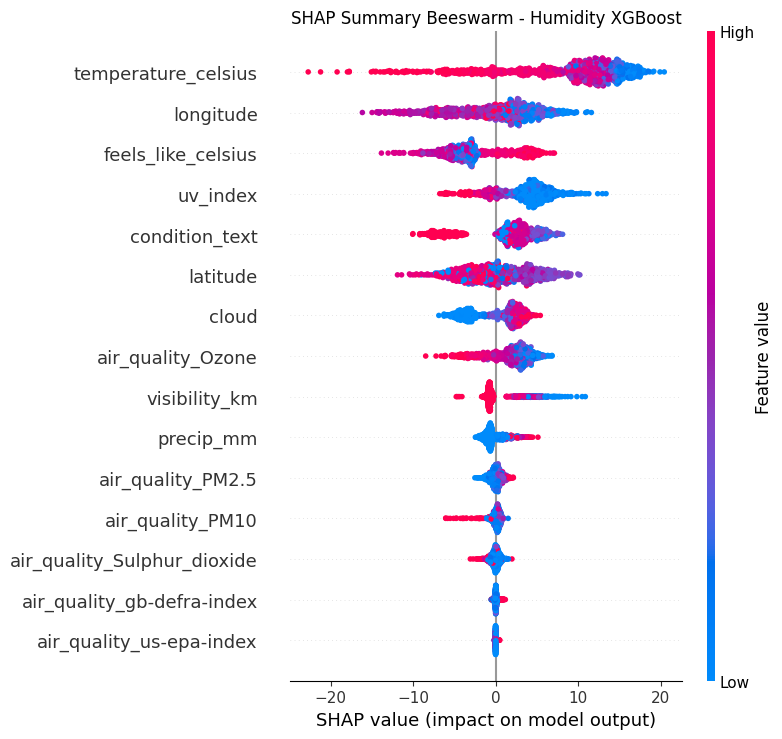

In [16]:
# ============================================================
# 1. SHAP Summary Beeswarm
# ============================================================

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X_sample.columns,
    show=False
)

plt.title("SHAP Summary Beeswarm - Humidity XGBoost")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/01_SHAP_Summary_Beeswarm_Humidity_XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

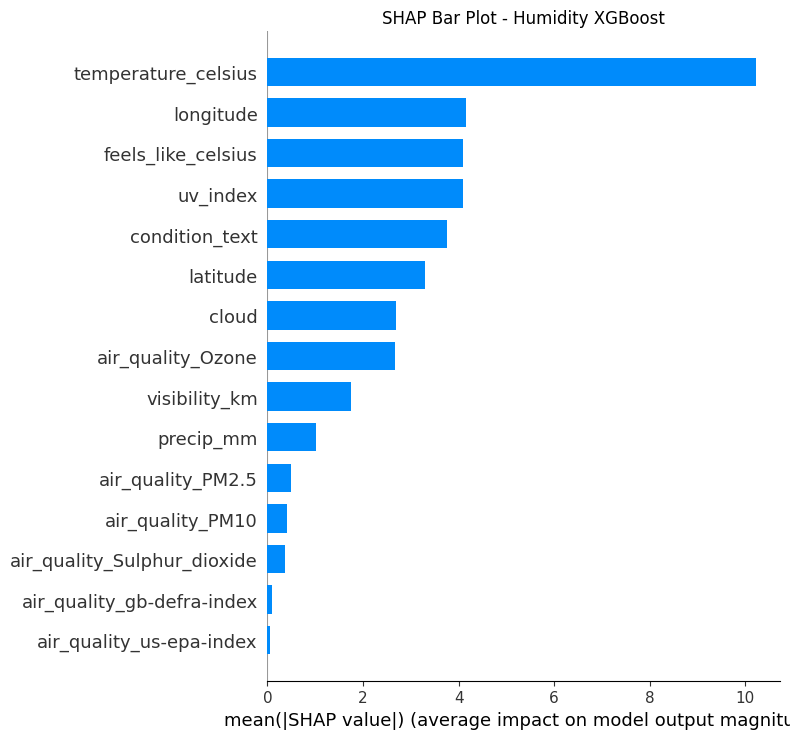

In [17]:
# ============================================================
# 2. SHAP Bar Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X_sample.columns,
    plot_type="bar",
    show=False
)

plt.title("SHAP Bar Plot - Humidity XGBoost")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/02_SHAP_Bar_Humidity_XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

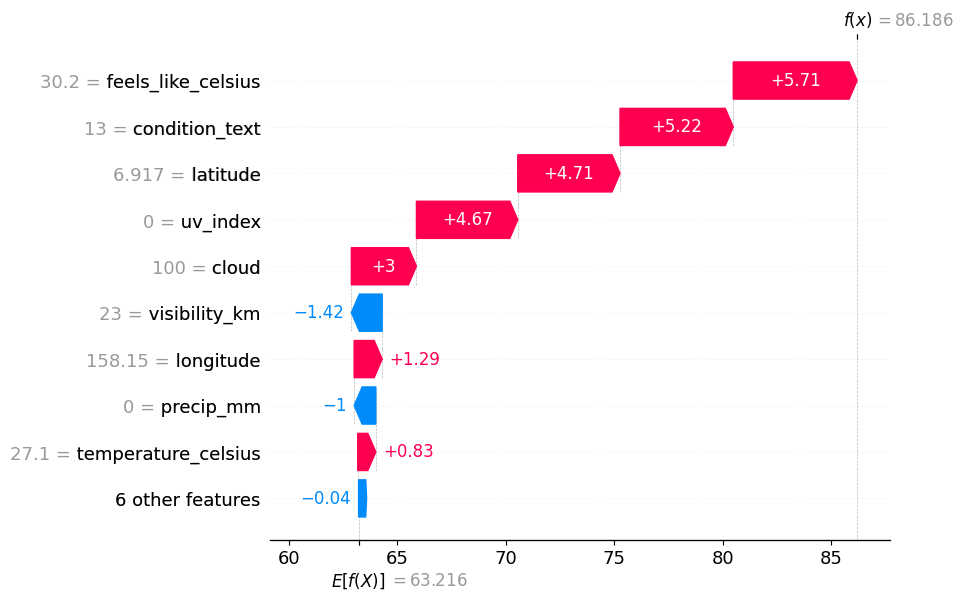

In [18]:
# ============================================================
# 3. SHAP Waterfall Plot
# ============================================================

sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_sample.iloc[sample_index],
    feature_names=X_sample.columns
)

shap.plots.waterfall(
    explanation,
    show=False
)

plt.savefig(
    f"{save_dir}/03_SHAP_Waterfall_Humidity_XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Top 3 SHAP Features:
['temperature_celsius', 'longitude', 'feels_like_celsius']


,Feature,Mean_ABS_SHAP
4,temperature_celsius,10.217046
8,longitude,4.146029
5,feels_like_celsius,4.102187
0,uv_index,4.082894
2,condition_text,3.757163
14,latitude,3.292033
1,cloud,2.699024
3,air_quality_Ozone,2.665439
12,visibility_km,1.752681
9,precip_mm,1.025101


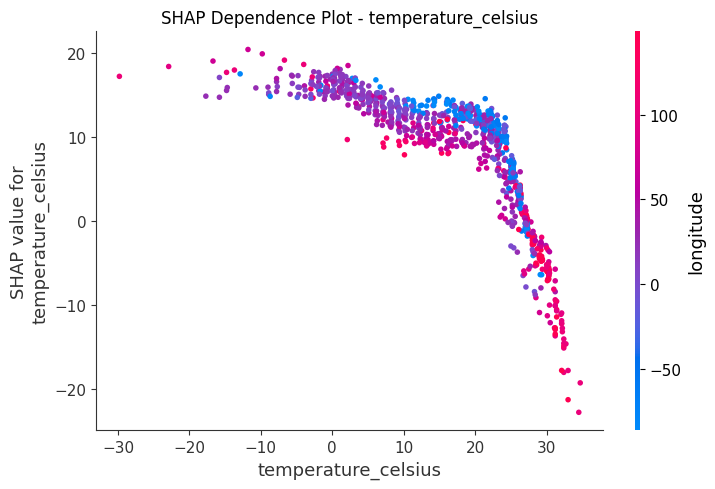

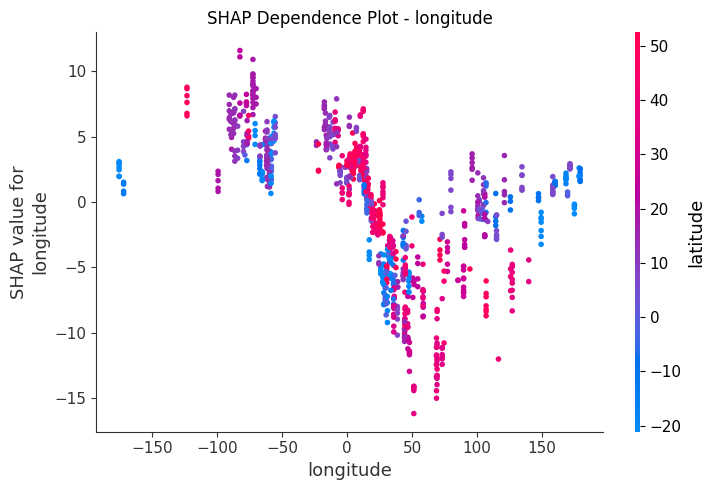

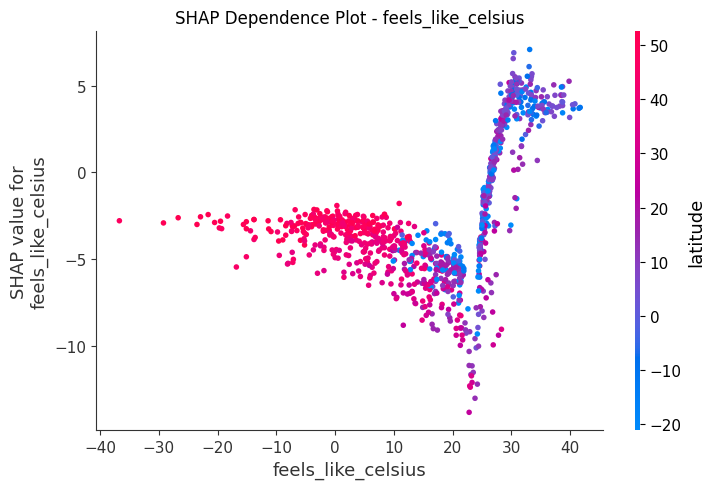

In [19]:
# ============================================================
# 4. SHAP Dependence Plot - Top 3 Features
# ============================================================

shap_importance = np.abs(shap_values).mean(axis=0)

top3_features = X_sample.columns[
    np.argsort(shap_importance)[::-1][:3]
]

top_features_df = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean_ABS_SHAP": shap_importance
}).sort_values(by="Mean_ABS_SHAP", ascending=False)

top_features_df.to_csv(
    f"{save_dir}/Humidity_XGBoost_SHAP_Feature_Importance.csv",
    index=False
)

print("Top 3 SHAP Features:")
print(list(top3_features))

display(top_features_df.head(15))

for feature in top3_features:

    shap.dependence_plot(
        feature,
        shap_values,
        X_sample,
        interaction_index="auto",
        show=False
    )

    plt.title(f"SHAP Dependence Plot - {feature}")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/04_SHAP_Dependence_{safe_name(feature)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

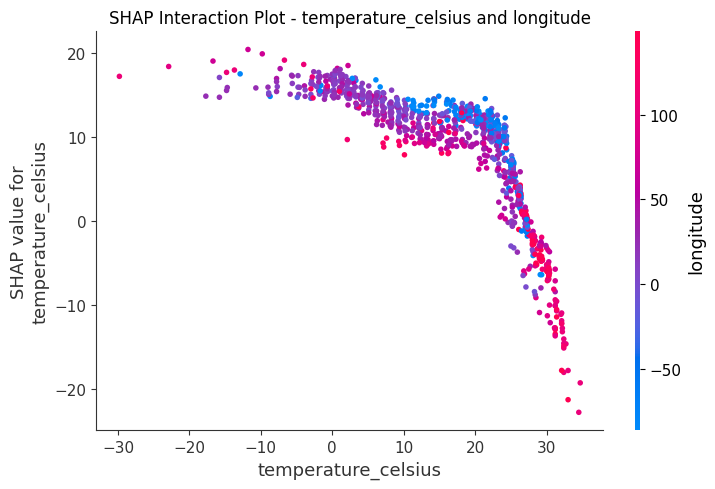

In [20]:
# ============================================================
# 5. SHAP Interaction Plot
# ============================================================

feature1 = top3_features[0]
feature2 = top3_features[1]

shap.dependence_plot(
    feature1,
    shap_values,
    X_sample,
    interaction_index=feature2,
    show=False
)

plt.title(f"SHAP Interaction Plot - {feature1} and {feature2}")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/05_SHAP_Interaction_{safe_name(feature1)}_{safe_name(feature2)}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

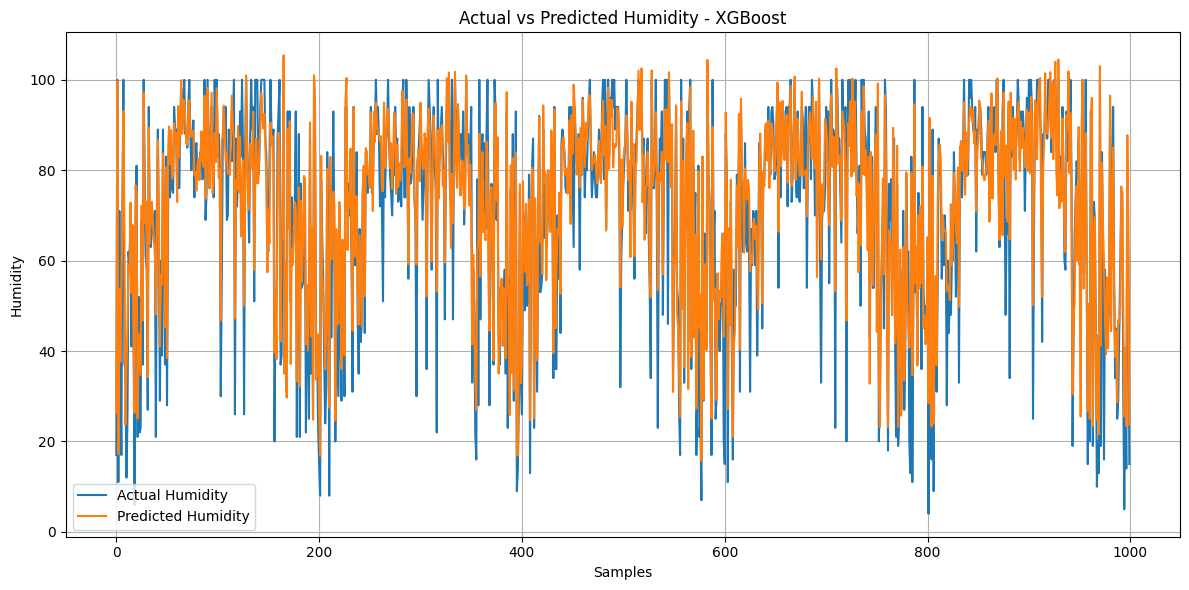

In [21]:
# ============================================================
# 6. Actual vs Predicted Plot
# ============================================================

xgb_pred = xgb_model.predict(X_test)

plot_n = min(1000, len(y_test))

plt.figure(figsize=(12, 6))

plt.plot(
    np.array(y_test[:plot_n]),
    label="Actual Humidity"
)

plt.plot(
    np.array(xgb_pred[:plot_n]),
    label="Predicted Humidity"
)

plt.title("Actual vs Predicted Humidity - XGBoost")
plt.xlabel("Samples")
plt.ylabel("Humidity")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/06_Actual_vs_Predicted_Humidity_XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

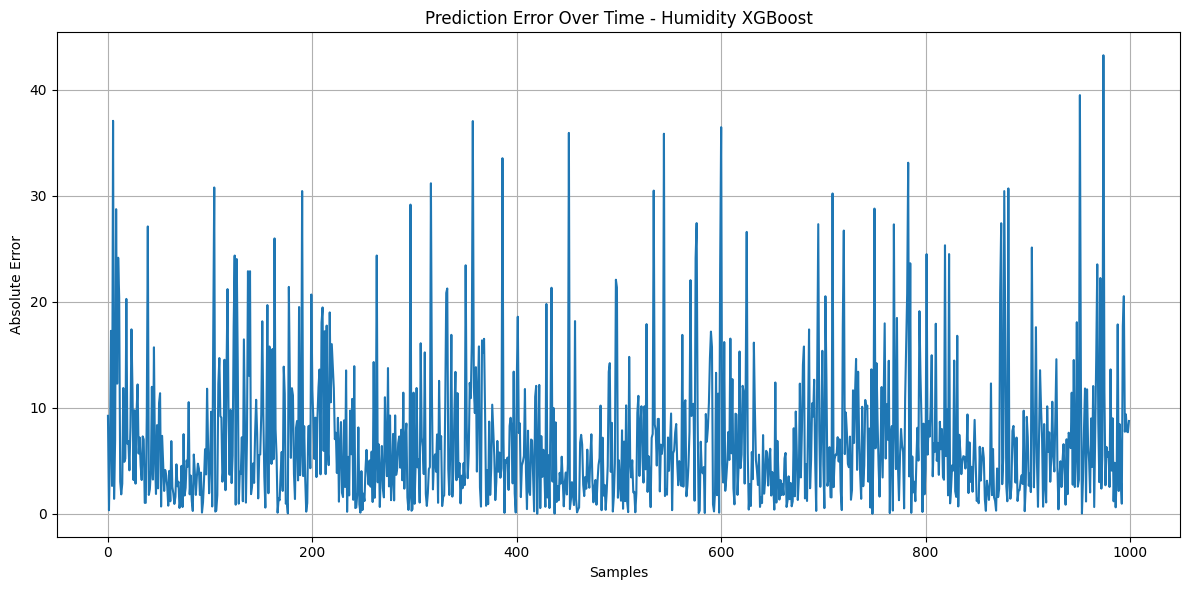

In [22]:
# ============================================================
# 7. Error Over Time Plot
# ============================================================

error = np.abs(np.array(y_test) - np.array(xgb_pred))

plt.figure(figsize=(12, 6))

plt.plot(error[:plot_n])

plt.title("Prediction Error Over Time - Humidity XGBoost")
plt.xlabel("Samples")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/07_Error_Over_Time_Humidity_XGBoost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [23]:
# ============================================================
# 8. Save Metrics
# ============================================================

mse = mean_squared_error(y_test, xgb_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, xgb_pred)
r2 = r2_score(y_test, xgb_pred)

metrics_df = pd.DataFrame({
    "Target": ["Humidity"],
    "Model": ["XGBoost"],
    "MSE": [mse],
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2],
    "Accuracy (%)": [r2 * 100]
})

metrics_df.to_csv(
    f"{save_dir}/Humidity_XGBoost_Metrics.csv",
    index=False
)

display(metrics_df)

,Target,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,Humidity,XGBoost,170.944305,13.074567,9.10982,0.643408,64.340836


In [24]:
# ============================================================
# 9. ZIP and Download All Outputs
# ============================================================

zip_path = "/content/Humidity_XGBoost_SHAP_All_Plots.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for root, dirs, files_list in os.walk(save_dir):
        for file in files_list:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>